# Gradient Boosting en GridSearch


## De gegevens

### Paddestoelen: eetbaar of giftig?

Data Source: https://archive.ics.uci.edu/ml/datasets/Mushroom


Deze dataset bevat beschrijvingen van hypothetische stalen die overeenkomen met 23 soorten paddenstoelen met plaatjes uit de Agaricus- en Lepiota-familie (pp. 500-525). Elke soort is geïdentificeerd als absoluut eetbaar, absoluut giftig, of van onbekende eetbaarheid en wordt niet aanbevolen. Deze laatste categorie werd gecombineerd met de giftige. De Gids stelt duidelijk dat er geen eenvoudige regel is om de eetbaarheid van een paddenstoel te bepalen.


Attribute Information:

1. cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s
2. cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s
3. cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r, pink=p,purple=u,red=e,white=w,yellow=y
4. bruises?: bruises=t,no=f
5. odor: almond=a,anise=l,creosote=c,fishy=y,foul=f, musty=m,none=n,pungent=p,spicy=s
6. gill-attachment: attached=a,descending=d,free=f,notched=n
7. gill-spacing: close=c,crowded=w,distant=d
8. gill-size: broad=b,narrow=n
9. gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e, white=w,yellow=y
10. stalk-shape: enlarging=e,tapering=t
11. stalk-root: bulbous=b,club=c,cup=u,equal=e, rhizomorphs=z,rooted=r,missing=?
12. stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s
13. stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s
14. stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y
15. stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y
16. veil-type: partial=p,universal=u
17. veil-color: brown=n,orange=o,white=w,yellow=y
18. ring-number: none=n,one=o,two=t
19. ring-type: cobwebby=c,evanescent=e,flaring=f,large=l, none=n,pendant=p,sheathing=s,zone=z
20. spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r, orange=o,purple=u,white=w,yellow=y
21. population: abundant=a,clustered=c,numerous=n, scattered=s,several=v,solitary=y
22. habitat: grasses=g,leaves=l,meadows=m,paths=p, urban=u,waste=w,woods=d

## Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/mushrooms.csv")

In [3]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## Voorbereiden van de data

In [4]:
X = df.drop('class',axis=1)

In [5]:
y = df['class']

In [6]:
X = pd.get_dummies(X,drop_first=True)

In [7]:
X.head()

,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,1,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,1,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,1,0,0,0
3,0,0,0,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
4,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [8]:
y.head()

0    p
1    e
2    e
3    p
4    e
Name: class, dtype: object

## Train Test Split 

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=101)

## Gradient Boosting and Grid Search with CV

GradientBoostingClassifier werkt best met Decision trees.  Daarom zijn de default values allemaal zo ingesteld.  De max_depth is hier niet meer default gelijk aan 1 maar aan 3!  Learning_rate is default 0.1, en n_estimators 100. Er zijn veel hyperparameters, dus is het best om de optimale hyperparameters te laten kiezen via GridSearch.

In [11]:
# help(GradientBoostingClassifier)

In [12]:
from sklearn.ensemble import GradientBoostingClassifier   # of Regressor

In [13]:
# opzetten gridsearch
from sklearn.model_selection import GridSearchCV

In [14]:
param_grid = {"n_estimators":[1,5,10,20,40,100],'max_depth':[3,4,5,6], 'learning_rate':[0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4]}

In [15]:
gb_model = GradientBoostingClassifier()

In [16]:
grid = GridSearchCV(gb_model,param_grid)

### Fit op Training Data met CV Search

In [17]:
grid.fit(X_train,y_train)

GridSearchCV(estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.02, 0.05, 0.1, 0.15, 0.2, 0.3,
                                           0.4],
                         'max_depth': [3, 4, 5, 6],
                         'n_estimators': [1, 5, 10, 20, 40, 100]})

In [18]:
grid.best_params_

{'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 100}

## Performance 

In [19]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, ConfusionMatrixDisplay

In [20]:
predictions = grid.predict(X_test)

In [21]:
predictions

array(['p', 'e', 'p', ..., 'p', 'p', 'e'], dtype=object)

In [22]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       655
           p       1.00      1.00      1.00       564

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



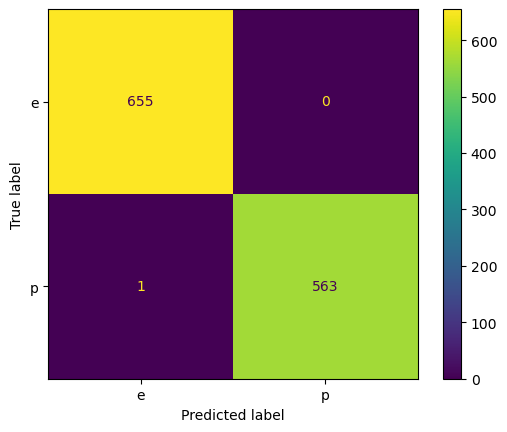

In [23]:
cm = confusion_matrix(y_test, predictions, labels=grid.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=grid.classes_)
disp.plot()

Zo goed als perfect rapport!

In [24]:
# opgepast: de feature_importances_ zijn beschikbaar na best_estimator_ en niet direct na grid!
grid.best_estimator_.feature_importances_

array([5.80512989e-04, 1.60996538e-15, 0.00000000e+00, 0.00000000e+00,
       5.21475743e-16, 1.73911174e-03, 3.85839994e-16, 5.72900509e-17,
       0.00000000e+00, 0.00000000e+00, 4.81457333e-17, 3.01947918e-16,
       2.04409665e-16, 0.00000000e+00, 0.00000000e+00, 2.69691007e-06,
       4.90875069e-16, 3.03761789e-02, 0.00000000e+00, 5.21100220e-03,
       8.83738838e-03, 1.39722681e-03, 6.23718380e-01, 9.46977752e-03,
       0.00000000e+00, 0.00000000e+00, 2.48806451e-18, 2.28005587e-03,
       1.92407221e-03, 0.00000000e+00, 4.93207670e-16, 1.37455195e-17,
       1.34002430e-17, 8.14256701e-16, 0.00000000e+00, 1.37255458e-16,
       1.88268638e-16, 9.48979658e-18, 9.84136288e-16, 0.00000000e+00,
       1.07001884e-04, 4.74133864e-04, 1.50679253e-01, 7.24126488e-03,
       4.45933161e-02, 3.27289132e-04, 8.42883424e-04, 0.00000000e+00,
       3.03933623e-18, 8.16243109e-04, 3.99824279e-02, 1.89945109e-03,
       0.00000000e+00, 0.00000000e+00, 3.30839628e-04, 0.00000000e+00,
      

In [25]:
feat_import = grid.best_estimator_.feature_importances_

In [26]:
imp_feats = pd.DataFrame(index=X.columns,data=feat_import,columns=['Importance'])

In [27]:
imp_feats  
# veel kleine waarden die als 0 zijn te beschouwen!
# deze importances zijn niet de coëfficiënten (die zijn allemaal identiek bij Gradient Boosting!) maar gebaseerd op de keuze 
# van het model inzake op welke features te splitten (features die veel informatie geven om op te splitten - de Gini Impurity waarde)

,Importance
cap-shape_c,5.805130e-04
cap-shape_f,1.609965e-15
cap-shape_k,0.000000e+00
cap-shape_s,0.000000e+00
cap-shape_x,5.214757e-16
...,...
habitat_l,5.735853e-06
habitat_m,1.395260e-16
habitat_p,3.091833e-18
habitat_u,5.019187e-18


In [28]:
imp_feats.sort_values("Importance",ascending=False)

,Importance
odor_n,0.623718
stalk-root_c,0.150679
stalk-root_r,0.044593
stalk-surface-below-ring_y,0.039982
bruises_t,0.030376
...,...
stalk-color-below-ring_n,0.000000
stalk-color-below-ring_o,0.000000
stalk-color-below-ring_p,0.000000
stalk-color-below-ring_y,0.000000


In [29]:
imp_feats.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Importance,95.0,0.010526,0.065829,0.0,0.0,1.882686e-16,0.000773,0.623718


In [30]:
imp_feats = imp_feats[imp_feats['Importance'] > 0.001]

In [31]:
imp_feats.sort_values('Importance')

,Importance
stalk-color-below-ring_c,0.001054
stalk-color-below-ring_w,0.001356
odor_m,0.001397
cap-surface_g,0.001739
stalk-color-above-ring_c,0.001899
gill-size_n,0.001924
ring-number_o,0.002033
gill-spacing_w,0.002280
ring-type_p,0.003239
odor_f,0.005211


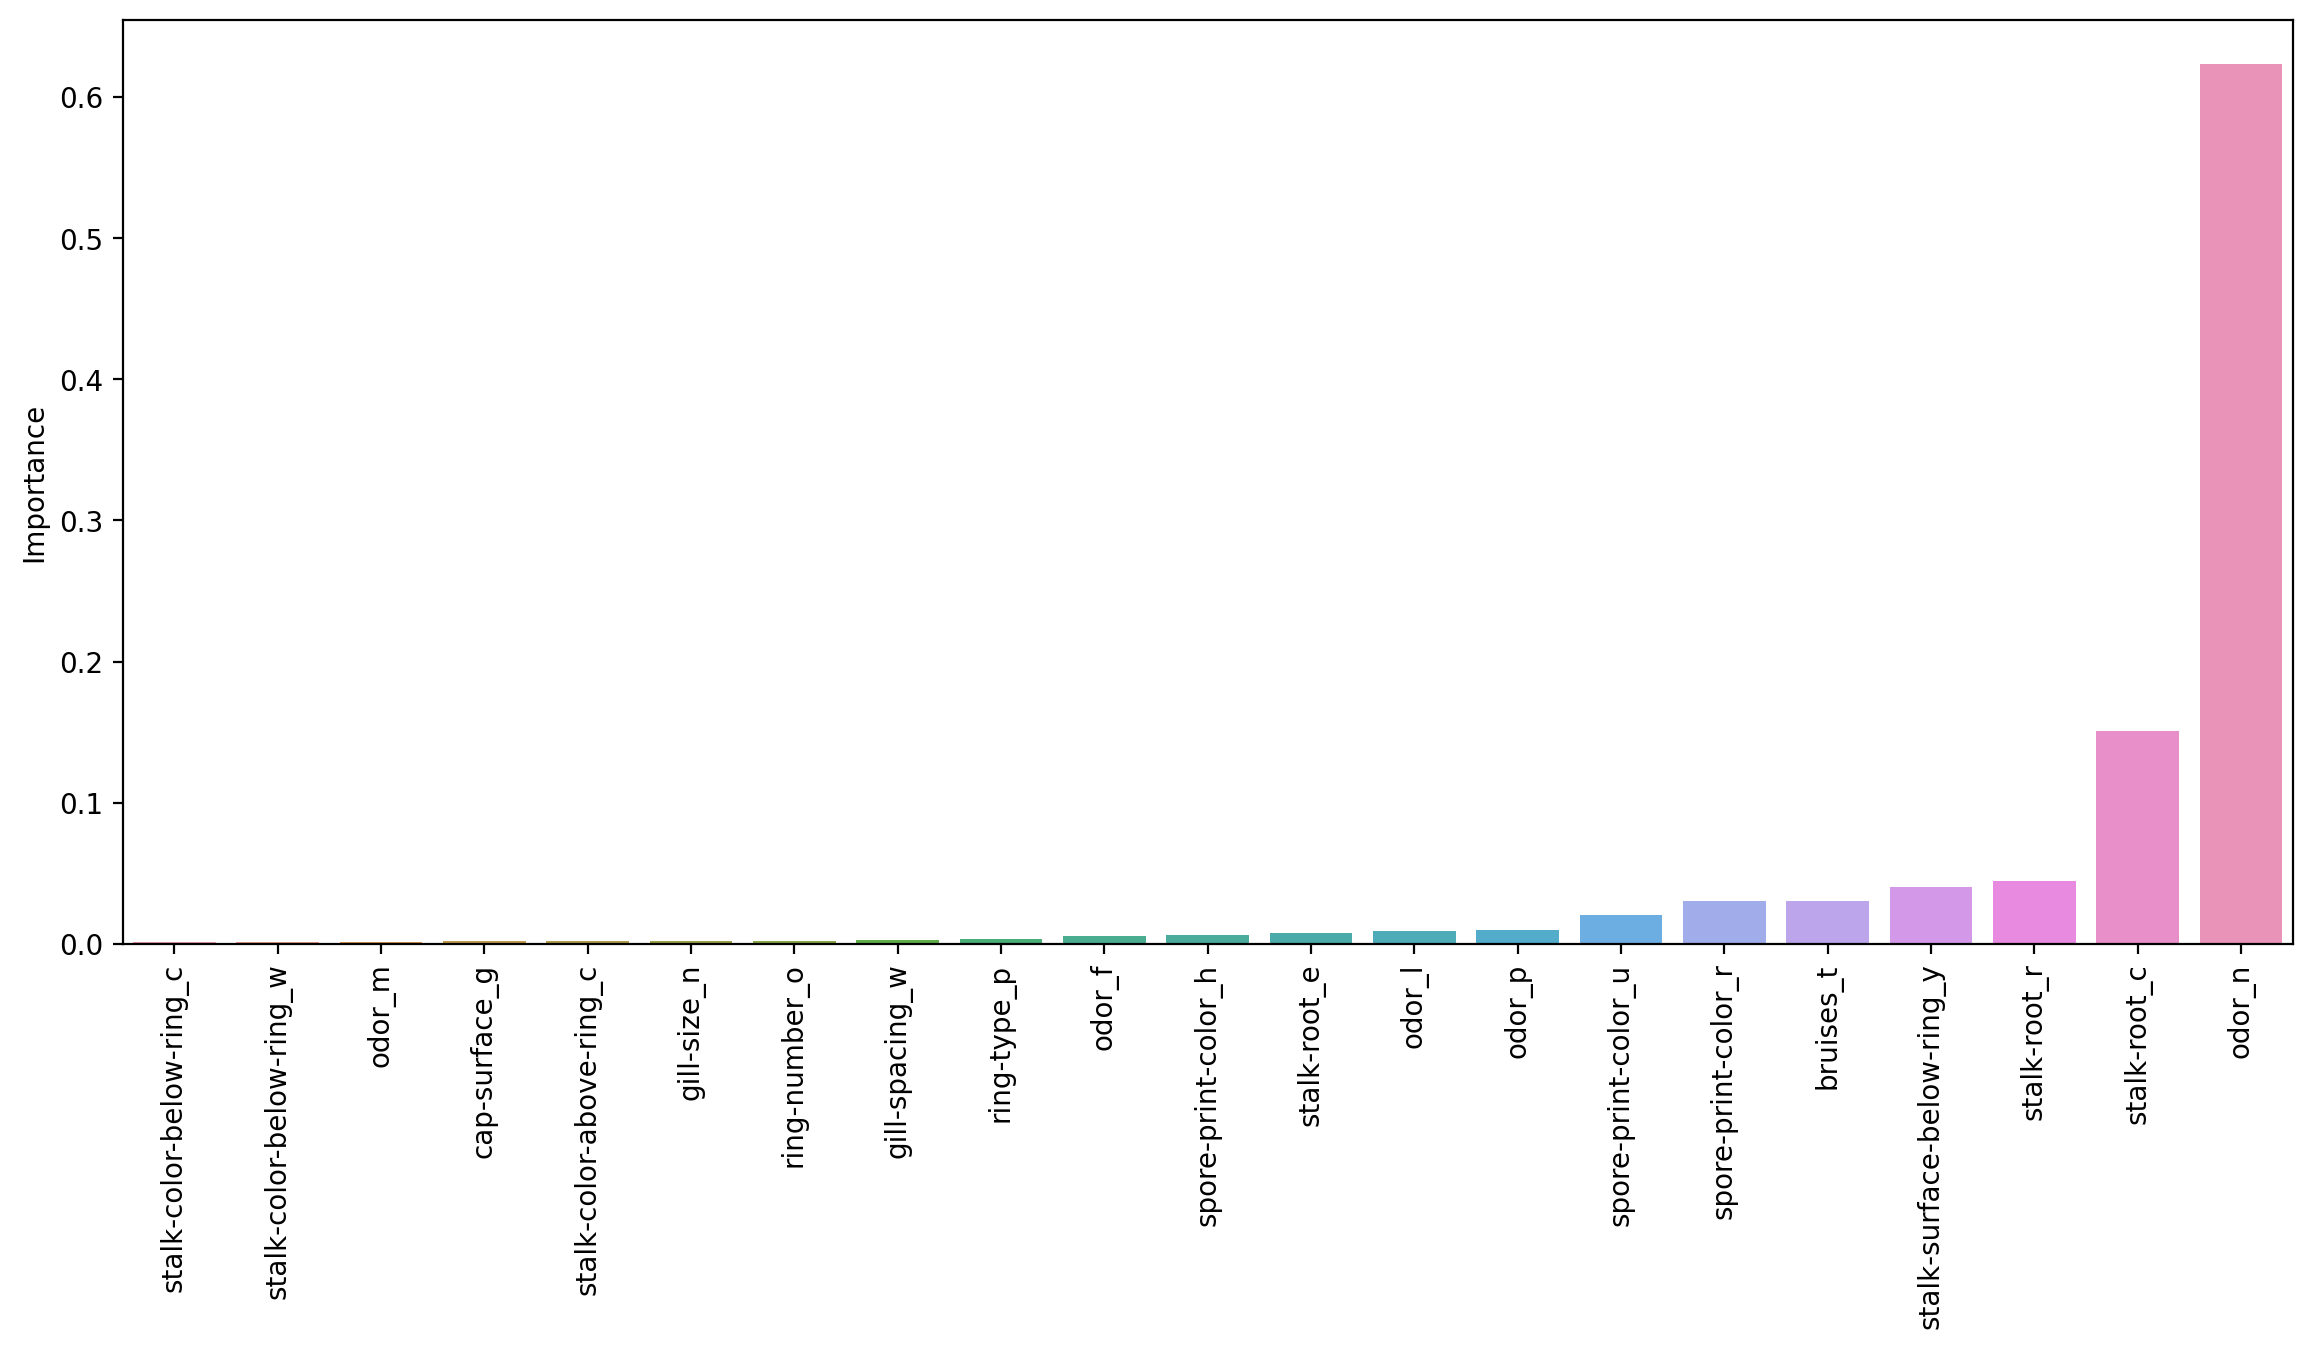

In [32]:
plt.figure(figsize=(14,6),dpi=200)
sns.barplot(data=imp_feats.sort_values('Importance'),x=imp_feats.sort_values('Importance').index,y='Importance')
plt.xticks(rotation=90);